In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Exploracion y limpieza

Primero vamos a realizar la exploracion y limpieza de datos como ya lo hemos venidoa haciedno, primero vamos a mirar si existen nulos, duplicados, que sean consistentes las variables categoricas y revisar si los datos tienen sentido, ej: Que el BMI sea razonable es decir valores entre 15 y 50, tambien evaluaremos si datos extremos son posibles o representan errores.

In [23]:
df = pd.read_csv('Datos_Laboratorio3.csv', sep=';', encoding='ISO-8859-1')
datos = df.copy()
datos.describe()

,Edad,Peso,Altura,BMI,Horas_sueño,Cantidad_equipo,Tiempo_disponible,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua
count,9698.000000,9687.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000
mean,45.112601,92.622515,1.775047,30.131391,7.004382,2.988039,67.194061,0.201588,0.153846,0.227366,2.172252,0.285317,3.778841,0.500115,129.997360,9765.936482,2.748532
std,17.641045,27.383913,0.158754,10.605675,1.449454,2.018493,30.839475,0.401207,0.360820,0.419153,4.624756,0.451588,7.023263,0.289062,51.981874,4762.152079,1.015342
min,15.000000,45.000000,1.500000,10.930000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.000000,200.000000,1.000000
25%,30.000000,68.800000,1.640000,21.620000,5.800000,1.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,85.000000,5608.250000,1.860000
50%,45.000000,92.600000,1.780000,29.190000,7.000000,3.000000,67.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,129.950000,9718.000000,2.760000
75%,61.000000,116.500000,1.910000,37.060000,8.200000,5.000000,94.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.300000,0.750000,175.200000,13953.000000,3.620000
max,75.000000,140.000000,2.050000,62.090000,23.000000,6.000000,120.000000,1.000000,1.000000,1.000000,18.000000,1.000000,25.000000,1.000000,220.000000,17996.000000,4.500000


Aqui vemos que el BMI tiene valores fuera dell rango razonable, minimo de 10 y maximo de 62, hay horas de sueño de 0 y 23 algo imposible en ambos casos, hay un maximo de 25 en consumo alcohol pero no tenemos la escala en la que se mide esta variable pero al ver que el maximo de cigarrillos dia es 18 podemos decir que estas variables estan en una escala razonable y posible. En este caso a comparacion del anterior es posible que haya registros con edades < 18 ya que es un gimnasio en donde pueden entrar personas de todas las edades.

In [24]:
(datos.isnull().sum() / datos.shape[0]).sort_values(ascending=False)

Peso                       0.001134
Edad                       0.000000
Tiene_alergia              0.000000
Plan_entrenamiento         0.000000
Ingesta_agua               0.000000
Pasos_dia                  0.000000
Ingesta_proteinas          0.000000
Score_micronutrientes      0.000000
Alcohol_semana             0.000000
Alcohol                    0.000000
Cigarrillos_dia            0.000000
Fumador                    0.000000
Problemas_digestivos       0.000000
Tiempo_disponible          0.000000
Gnereo                     0.000000
Cantidad_equipo            0.000000
Entrenamiento_preferido    0.000000
Horas_sueño                0.000000
Dieta_preferida            0.000000
Nivel_experiencia          0.000000
Nivel_Actividad            0.000000
Condicion_salud            0.000000
Objetivo                   0.000000
BMI                        0.000000
Altura                     0.000000
Plan_nutrición             0.000000
dtype: float64

Vemos que solo hay nulos en peso lo cual no importa ya que seguramente borremos la variable debido a que el BMI aporta mucha mas informacion que solo el peso

In [25]:
datos.duplicated().sum()

np.int64(0)

No hay duplicados.

In [26]:
for col in datos.select_dtypes(include='object').columns:
    print(datos[col].value_counts())

Gnereo
Femenino     4719
Masculino    4611
Otro          368
Name: count, dtype: int64
Objetivo
Ganancia muscular    2757
Perdida grasa        2594
General              2220
Resistencia          2123
grasa                   4
Name: count, dtype: int64
Condicion_salud
Ninguno               6030
Hipertension           814
Lesion                 764
Asma                   745
Diabetes               511
Enfermedad corazon     497
PCOS                   337
Name: count, dtype: int64
Nivel_Actividad
Moderado    3594
Bajo        3326
Alto        2778
Name: count, dtype: int64
Nivel_experiencia
Intermedio      4100
Principiante    3608
Avanzado        1990
Name: count, dtype: int64
Dieta_preferida
No-Vegetariano    2456
Vegano            2426
Pescetariano      2403
Vegetariano       2402
Animal              11
Name: count, dtype: int64
Entrenamiento_preferido
Funcional       1666
Hit             1620
Flexibilidad    1618
Cardio          1602
Fuerza          1601
Balance         1591
Name: coun

Aqui vemos que la categoria objetivo tiene el valor "grasa" que es razonable pensar que deberia ser "Perdida grasa", en dieta esta "Animal" que se puede poner en "No-Vegetariano" ya que animal tiene solo 11 registros y No-Vegetarino mas de 2000 por lo que debe ser un error. El resto de variables son consistentes.

<Axes: >

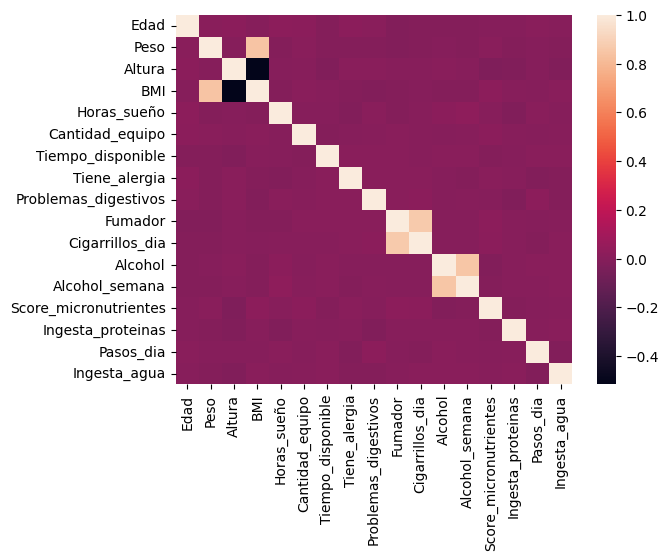

In [27]:
sns.heatmap(datos.corr(numeric_only=True))

Con lo visto anteriormente es posible ver que hay correlacion entre Fumador y Cigarrillos_dia y Alcohol y Alcohol_Semana lo cual tiene sentido por lo que vamos a quitar las variables categoricas Fumador y Alcohol ya que con las numericas solas es posible saber si es fumador o consumidor de alcohol, estas variables sobran y crean correlacion, ademas vamos a quitar la variable peso ya que esta correlacionada con BMI y esta ultima aporta mayor informacion que solo el peso. Vamos a corregir las variables categoricas que nos son consistentes y vamos a revisar los valores extremos de BMI para revisar si son errores o outliers. Aunque altura tambien este correlacionada con BMI la vamos a dejar ya que esto no puede inferirse por el BMI (Un BMI alto indica un peso alto pero no necesariamente gran altura y viceversa) y nos puede aportar informacion importante para estructurar los entrenamientos de los usuarios del gimnasio, ademas al ser correlacion negativa no debe afectar el modelo.

In [28]:
datos = datos.drop(columns=['Peso', 'Alcohol', 'Fumador'])
print(datos[(datos['BMI'] > 55)].head(20))

      Edad     Gnereo  Altura    BMI           Objetivo Condicion_salud  \
118     66   Femenino    1.55  55.19        Resistencia         Ninguno   
221     38   Femenino    1.51  60.22      Perdida grasa         Ninguno   
457     18   Femenino    1.57  55.22      Perdida grasa         Ninguno   
489     57  Masculino    1.52  59.12  Ganancia muscular         Ninguno   
507     31  Masculino    1.52  58.17        Resistencia    Hipertension   
532     23  Masculino    1.52  59.21        Resistencia         Ninguno   
553     20  Masculino    1.53  56.30  Ganancia muscular         Ninguno   
566     66   Femenino    1.53  59.12            General            Asma   
740     52   Femenino    1.53  59.68      Perdida grasa         Ninguno   
1044    30   Femenino    1.51  57.28        Resistencia         Ninguno   
1115    27  Masculino    1.56  56.09  Ganancia muscular         Ninguno   
1172    18   Femenino    1.55  56.02      Perdida grasa    Hipertension   
1270    39  Masculino    

Despues de ver esto, vamos a quitar los BMI menores a 14 ya que esto es un caso extremo y es casi imposible tener un BMI menor a esto y vamos a quitar los superiores a 55 ya que esto representa una situacion de obesidad extrema y es muy poco probable que una persona en este estado pueda tener la movilidad para hacer los pasos que dicen los datos explorados en el paso anterior. Seguramente son errores en el set de datos. Ademas ahora si vamos a dejar solo datos con valores de horas de sueño aunque extremas, razonables. Para el resto de variables consideramos que tienen valores con sentido.

In [ ]:
datos = datos[(datos['BMI'] >= 15) & (datos['BMI'] <= 55)]
datos = datos[(datos['Horas_sueño']>4) & (datos['Horas_sueño']<16)]


# Regresion Logistica

In [33]:
X = datos.drop(columns=['Plan_entrenamiento', 'Plan_nutrición'])
y_entrena = datos['Plan_entrenamiento']
y_nutri = datos['Plan_nutrición']

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X, y_entrena, test_size=0.2, random_state=42, stratify=y_entrena
)

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X, y_nutri, test_size=0.2, random_state=42, stratify=y_nutri
)

num = ['Edad', 'Altura', 'BMI', 'Horas_sueño', 'Cantidad_equipo', 'Tiempo_disponible', 'Tiene_alergia', 'Problemas_digestivos', 'Cigarrillos_dia','Alcohol_semana','Score_micronutrientes','Ingesta_proteinas','Pasos_dia','Ingesta_agua'] 
cat = ['Gnereo', 'Objetivo','Condicion_salud','Nivel_Actividad','Nivel_experiencia', 'Dieta_preferida', 'Entrenamiento_preferido']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat)
])

pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear', 'saga']
}

grid_search_entrena = GridSearchCV(
    pipeline_lr, param_grid, cv=5,
    scoring='f1_weighted', n_jobs=-1
)
grid_search_entrena.fit(X_train_e, y_train_e)

grid_search_nutri = GridSearchCV(
    pipeline_lr, param_grid, cv=5,
    scoring='f1_weighted', n_jobs=-1
)
grid_search_nutri.fit(X_train_n, y_train_n)

print("Mejores parámetros entrenamiento:", grid_search_entrena.best_params_)
print("Mejores parámetros nutrición:", grid_search_nutri.best_params_)

/Users/lucas/.pyenv/versions/3.9.8/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/lucas/.pyenv/versions/3.9.8/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/lucas/.pyenv/versions/3.9.8/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/lucas/.pyenv/versions/3.9.8/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/lucas/.pyenv/versions/3.9.8/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/luc

Mejores parámetros entrenamiento: {'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}
Mejores parámetros nutrición: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}


# Arbol de decision

In [34]:
pipeline_arbol = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

param_grid_arbol = {
    'classifier__max_depth': [3, 5, 10, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__criterion': ['gini', 'entropy']
}

grid_arbol_e = GridSearchCV(
    pipeline_arbol, param_grid_arbol, cv=5,
    scoring='f1_weighted', n_jobs=-1
)
grid_arbol_e.fit(X_train_e, y_train_e)

grid_arbol_n = GridSearchCV(
    pipeline_arbol, param_grid_arbol, cv=5,
    scoring='f1_weighted', n_jobs=-1
)
grid_arbol_n.fit(X_train_n, y_train_n)

print("Mejores parámetros entrenamiento:", grid_arbol_e.best_params_)
print("Mejores parámetros nutrición:", grid_arbol_n.best_params_)

Mejores parámetros entrenamiento: {'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Mejores parámetros nutrición: {'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}


# Tabla comparativa

In [35]:
def extraer_metricas(model, X_test, y_test, nombre_modelo, objetivo):
    y_pred = model.best_estimator_.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    return {
        'Modelo': nombre_modelo,
        'Objetivo': objetivo,
        'Precision': round(report['weighted avg']['precision'], 4),
        'Recall': round(report['weighted avg']['recall'], 4),
        'F1-Score': round(report['weighted avg']['f1-score'], 4)
    }

resultados = [
    extraer_metricas(grid_search_entrena,  X_test_e, y_test_e, 'Regresión Logística', 'Plan Entrenamiento'),
    extraer_metricas(grid_search_nutri,    X_test_n, y_test_n, 'Regresión Logística', 'Plan Nutrición'),
    extraer_metricas(grid_arbol_e, X_test_e, y_test_e, 'Árbol de Decisión',  'Plan Entrenamiento'),
    extraer_metricas(grid_arbol_n,   X_test_n, y_test_n, 'Árbol de Decisión',  'Plan Nutrición'),
]

tabla = pd.DataFrame(resultados).set_index(['Objetivo', 'Modelo'])
tabla

,,Precision,Recall,F1-Score
Objetivo,Modelo,,,
Plan Entrenamiento,Regresión Logística,0.8803,0.8794,0.8798
Plan Nutrición,Regresión Logística,0.7947,0.8003,0.7954
Plan Entrenamiento,Árbol de Decisión,0.9989,0.9989,0.9989
Plan Nutrición,Árbol de Decisión,0.9961,0.9961,0.9961


# Esta sobreentrenado el arbol?

In [37]:
# Compara train vs test
y_pred_train = grid_arbol_e.best_estimator_.predict(X_train_e)
y_pred_test = grid_arbol_e.best_estimator_.predict(X_test_e)

print("Train F1:", f1_score(y_train_e, y_pred_train, average='weighted'))
print("Test F1: ", f1_score(y_test_e,  y_pred_test,  average='weighted'))

# También revisa qué hiperparámetros ganaron
print(grid_arbol_e.best_params_)

Train F1: 0.9998617243525079
Test F1:  0.9988937520436083
{'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
